In [1]:
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# Model + tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calibration
from sklearn.calibration import CalibratedClassifierCV

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

df = df.drop_duplicates()

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
target = "Revenue"

X = df.drop(target, axis=1)
y = df[target]

In [4]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [5]:
def log_transform(X):
    return np.log1p(X)

In [6]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(log_transform)),
    ("scaler", StandardScaler())
])

In [7]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [8]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [9]:
X_processed = preprocessor.fit_transform(X)

In [10]:
selector = SelectKBest(score_func=f_classif, k=15)

X_selected = selector.fit_transform(X_processed, y)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_log_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


In [13]:
calibrated_model = CalibratedClassifierCV(best_log_model)
calibrated_model.fit(X_train, y_train)

,estimator,LogisticRegre...r='liblinear')
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1


In [14]:
y_prob = calibrated_model.predict_proba(X_test)[:, 1]


threshold = 0.3
y_final = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

       False       0.95      0.92      0.93      2059
        True       0.62      0.72      0.67       382

    accuracy                           0.89      2441
   macro avg       0.79      0.82      0.80      2441
weighted avg       0.90      0.89      0.89      2441



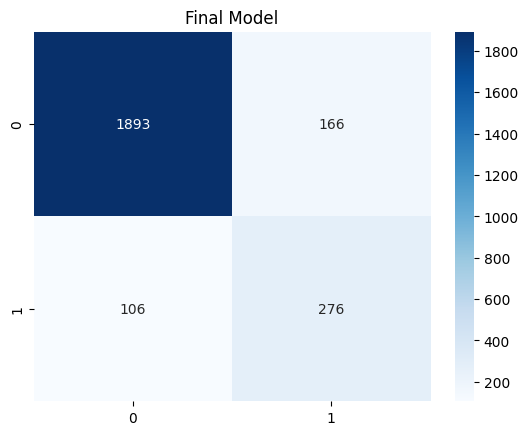

In [15]:
cm = confusion_matrix(y_test, y_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Final Model")
plt.show()

In [16]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", selector),
    ("model", CalibratedClassifierCV(best_log_model))
])

In [17]:
final_pipeline.fit(X, y)

'''
stores in this manner : for example:
final_model.pkl =
{
  preprocessing: {medians, scalers, encoders},
  selector: {selected feature indices},
  model: {weights, calibration},
  pipeline order: [preprocess → select → model]
}'''

'\nstores in this manner : for example:\nfinal_model.pkl =\n{\n  preprocessing: {medians, scalers, encoders},\n  selector: {selected feature indices},\n  model: {weights, calibration},\n  pipeline order: [preprocess → select → model]\n}'

In [18]:
import pickle

with open("final_model.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)